# E-Commerce Customer Segmentation using RFM and Clustering

## 1. Data Understanding

In [51]:
import pandas as pd

In [52]:
df = pd.read_excel('/content/part_1_ecommerce_customer_segmentation.xlsx')
display(df.head())

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4395 non-null   object        
 1   StockCode    4395 non-null   object        
 2   Description  4328 non-null   object        
 3   Category     4395 non-null   object        
 4   Quantity     4395 non-null   int64         
 5   InvoiceDate  4395 non-null   datetime64[ns]
 6   UnitPrice    4395 non-null   float64       
 7   CustomerID   4187 non-null   object        
 8   Country      4395 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 309.2+ KB


### Dataset Explanation

- **InvoiceNo**: Invoice number. A 6-digit integral number uniquely assigned to each transaction. If this code starts with 'c', it indicates a cancellation.
- **StockCode**: Product (item) code. A 5-digit integral number uniquely assigned to each distinct product.
- **Description**: Product (item) name.
- **Quantity**: The quantities of each product per transaction. This is a numeric value.
- **InvoiceDate**: Invoice date and time. The day and time when each transaction was generated. This is a datetime value.
- **UnitPrice**: Unit price. Product price per unit in sterling (£). This is a numeric value.
- **CustomerID**: Customer number. A 5-digit integral number uniquely assigned to each customer. If a row has a missing CustomerID, it means the transaction was not linked to a registered customer (e.g., a guest checkout).
- **Country**: Country name. The name of the country where each customer resides. This is a categorical value.

Each row in this dataset represents a single item within a larger transaction (invoice). For example, if a customer buys three different items in one purchase, there will be three separate rows, each with the same "InvoiceNo" but different "StockCode" and "Description".

This dataset belongs to an **online retail business** that sells various household and gift items.

### Potential Customer/Sales Analysis:

- **Customer Segmentation**: By analyzing purchasing patterns, we can group customers into segments (e.g., high-value, frequent, new, at-risk) using techniques like RFM (Recency, Frequency, Monetary) analysis and clustering.
- **Sales Performance**: Track sales trends over time, identify best-selling products, and understand revenue generation by product and country.
- **Product Analysis**: Identify popular products, product profitability, and cross-selling opportunities.
- **Geographical Analysis**: Understand which countries contribute most to sales and customer base.
- **Customer Lifetime Value (CLV)**: Predict the future value a customer will bring to the company.
- **Marketing Strategy Optimization**: Tailor marketing campaigns based on customer segments and product preferences.

### Business Questions Answered:

- Which customers are most valuable to the business?
- What are the peak sales periods?
- Which products should be promoted more?
- Are there specific countries where sales are particularly strong or weak?
- How often do customers make purchases?
- What is the average order value?

### Business Questions Not Answered (due to missing information):

- **Customer Demographics**: The dataset lacks information such as age, gender, income, or profession, which would be crucial for more precise demographic targeting.
- **Marketing Channel Effectiveness**: There's no data on how customers were acquired (e.g., referral, social media, ads), so we cannot analyze the performance of different marketing channels.
- **Website Behavior**: We don't have data on website visits, cart abandonment rates, or product views, which could provide insights into customer journey and conversion funnels.
- **Customer Satisfaction**: The dataset does not include customer feedback, ratings, or return reasons, making it impossible to directly measure customer satisfaction.
- **Operational Costs**: Without information on warehousing, shipping, or marketing spend, it's hard to calculate net profit per product or customer accurately.

## 2. Data Cleaning

### Handling Missing Customer IDs

In [54]:
print(f"Number of missing CustomerIDs before cleaning: {df['CustomerID'].isnull().sum()}")
# Need to drop rows with missing CustomerID as it is essential for customer segmentation.
df.dropna(subset=['CustomerID'], inplace=True)
print(f"Number of missing CustomerIDs after cleaning: {df['CustomerID'].isnull().sum()}")
display(df.head())

Number of missing CustomerIDs before cleaning: 208
Number of missing CustomerIDs after cleaning: 0


,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


### Handling Missing Product Descriptions

In [55]:
print(f"Number of missing Product Descriptions before cleaning: {df['Description'].isnull().sum()}")
# Product descriptions are critical for understanding the items. Hence, missing ones are dropped.
df.dropna(subset=['Description'], inplace=True)
print(f"Number of missing Product Descriptions after cleaning: {df['Description'].isnull().sum()}")
display(df.head())

Number of missing Product Descriptions before cleaning: 64
Number of missing Product Descriptions after cleaning: 0


,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


### Handling Negative or Zero Quantities

In [56]:
print(f"Number of rows with Quantity <= 0 before cleaning: {df[df['Quantity'] <= 0].shape[0]}")
# Remove rows where Quantity is less than or equal to 0, as these are invalid entries.
df = df[df['Quantity'] > 0]
print(f"Number of rows with Quantity <= 0 after cleaning: {df[df['Quantity'] <= 0].shape[0]}")
display(df.head())

Number of rows with Quantity <= 0 before cleaning: 183
Number of rows with Quantity <= 0 after cleaning: 0


,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


### Handling Zero or Negative Unit Prices

In [57]:
print(f"Number of rows with UnitPrice <= 0 before cleaning: {df[df['UnitPrice'] <= 0].shape[0]}")
# Remove rows where UnitPrice is less than or equal to 0.
df = df[df['UnitPrice'] > 0]
print(f"Number of rows with UnitPrice <= 0 after cleaning: {df[df['UnitPrice'] <= 0].shape[0]}")
display(df.head())

Number of rows with UnitPrice <= 0 before cleaning: 61
Number of rows with UnitPrice <= 0 after cleaning: 0


,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


### Handling Cancelled or Returned Invoices

In [58]:
print(f"Number of cancelled invoices before cleaning: {df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0]}")
# Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Number of cancelled invoices after cleaning: {df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0]}")
display(df.head())

Number of cancelled invoices before cleaning: 0
Number of cancelled invoices after cleaning: 0


,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


### Handling Duplicate Records

In [59]:
print(f"Number of duplicate rows before cleaning: {df.duplicated().sum()}")
# Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after cleaning: {df.duplicated().sum()}")
display(df.head())

Number of duplicate rows before cleaning: 31
Number of duplicate rows after cleaning: 0


,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


### Handling Incorrect Data Types

In [60]:
# Check current data types
print("Data types after cleaning:")
df.info()
# All data types appear to be appropriate for their respective columns:
# InvoiceDate is already datetime64[ns]
# Quantity is int
# UnitPrice is float
# CustomerID and InvoiceNo are object (string) which is suitable for identifiers
# Description, Category, and Country are object (string) which is suitable for categorical/text data.

Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 3848 entries, 0 to 4359
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    3848 non-null   object        
 1   StockCode    3848 non-null   object        
 2   Description  3848 non-null   object        
 3   Category     3848 non-null   object        
 4   Quantity     3848 non-null   int64         
 5   InvoiceDate  3848 non-null   datetime64[ns]
 6   UnitPrice    3848 non-null   float64       
 7   CustomerID   3848 non-null   object        
 8   Country      3848 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 300.6+ KB


## 3. Feature Engineering

### Calculate Total Revenue per Transaction

In [61]:
# Calculating Revenue for each transaction line item into new column Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']
display(df.head())

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE,468.04
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE,248.30
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India,3645.60
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands,659.20
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands,526.21


### Create Customer-Level Features

In [62]:
customer_features = df.groupby('CustomerID').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalPurchases=('InvoiceNo', 'nunique'),
    TotalQuantity=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique'),
    Country=('Country', lambda x: x.mode()[0]) # Get the most frequent country for the customer
).reset_index()
# Calculating Average Order Value into a new column.
customer_features['AverageOrderValue'] = customer_features['TotalRevenue'] / customer_features['TotalPurchases']
display(customer_features.head())

,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,UniqueProducts,Country,AverageOrderValue
0,C10001,22885.81,3,63,8,India,7628.603333
1,C10003,12061.04,1,10,3,United Kingdom,12061.040000
2,C10004,10579.97,2,16,5,United Kingdom,5289.985000
3,C10005,14154.57,2,17,7,Germany,7077.285000
4,C10006,27389.29,3,27,8,India,9129.763333


### Create RFM Table

In [63]:
# Calculate Recency, Frequency, and Monetary for each customer
# Set a reference date for recency calculation (one day after the last transaction in the dataset)
max_invoice_date = df['InvoiceDate'].max()
reference_date = max_invoice_date + pd.Timedelta(days=1)

rfm_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (reference_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

display(rfm_df.head())

,CustomerID,Recency,Frequency,Monetary
0,C10001,117,3,22885.81
1,C10003,33,1,12061.04
2,C10004,40,2,10579.97
3,C10005,297,2,14154.57
4,C10006,31,3,27389.29


## 4. Exploratory Data Analysis

### Which countries generate the highest sales?

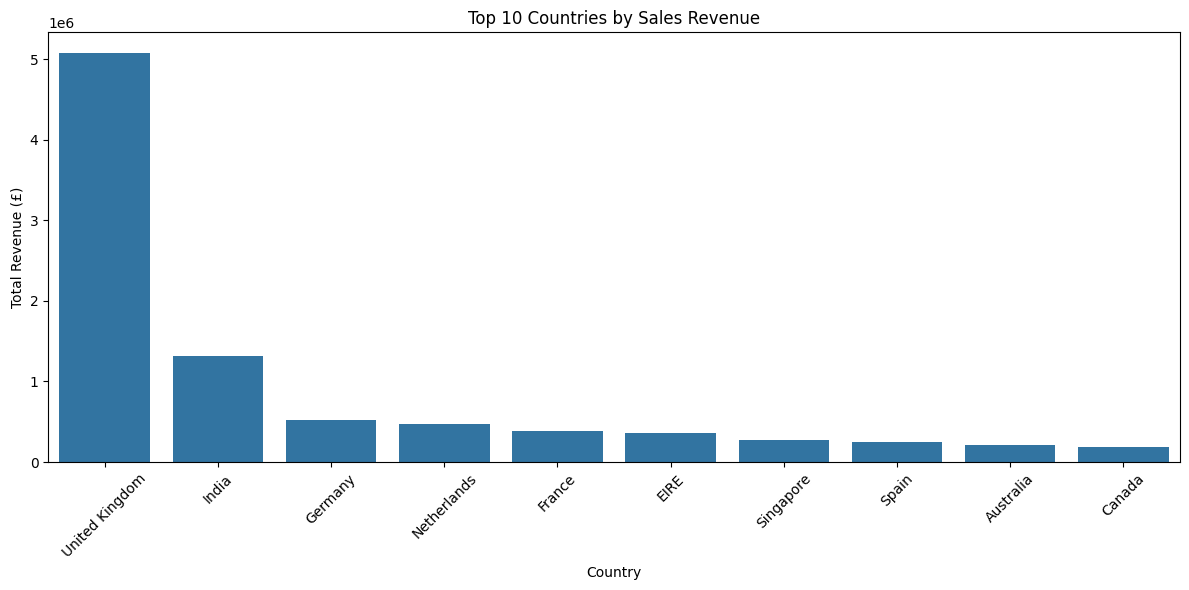

Interpretation: This chart highlights the top 10 countries generating the most sales, showing where our biggest markets are.

Top 10 Countries by Sales Revenue:
Country
United Kingdom    5077346.04
India             1317559.20
Germany            522952.30
Netherlands        471859.80
France             391165.98
EIRE               363629.09
Singapore          274964.06
Spain              245251.64
Australia          207927.20
Canada             186286.15
Name: Revenue, dtype: float64


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_sales.index, y=country_sales.values)
plt.title('Top 10 Countries by Sales Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Interpretation: This chart highlights the top 10 countries generating the most sales, showing where our biggest markets are.")
print("\nTop 10 Countries by Sales Revenue:")
print(country_sales)

### Which products are sold the most?

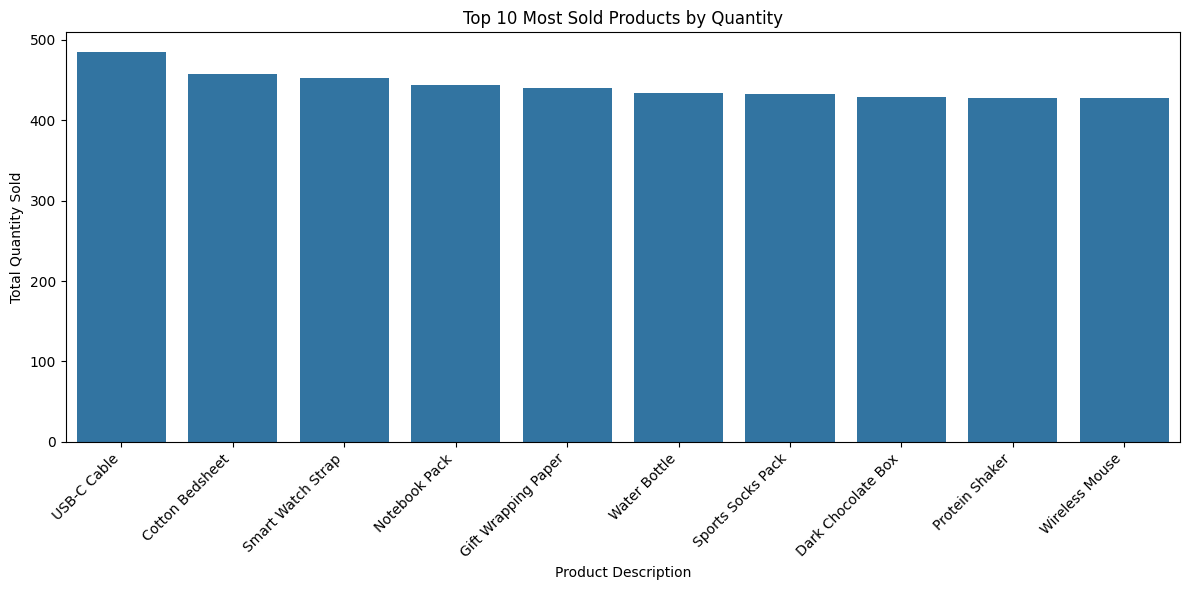

Interpretation: This chart shows ten most popular products based on the total number of units sold.

Top 10 Most Sold Products by Quantity:
Description
USB-C Cable            485
Cotton Bedsheet        457
Smart Watch Strap      453
Notebook Pack          444
Gift Wrapping Paper    440
Water Bottle           434
Sports Socks Pack      432
Dark Chocolate Box     429
Protein Shaker         428
Wireless Mouse         427
Name: Quantity, dtype: int64


In [65]:
product_sales = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=product_sales.index, y=product_sales.values)
plt.title('Top 10 Most Sold Products by Quantity')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretation: This chart shows ten most popular products based on the total number of units sold.")
print("\nTop 10 Most Sold Products by Quantity:")
print(product_sales)

### Which products generate the highest revenue?

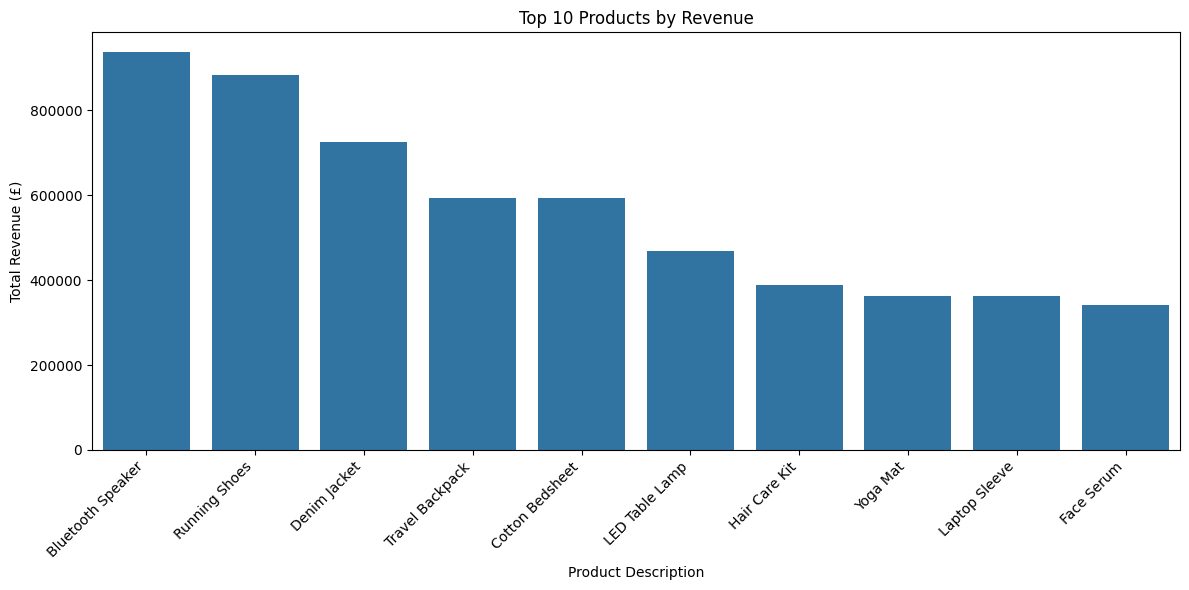

Interpretation: This chart displays the ten products that bring in the most revenue for business.

Top 10 Products by Revenue:
Description
Bluetooth Speaker    936458.19
Running Shoes        882656.10
Denim Jacket         725974.85
Travel Backpack      592789.30
Cotton Bedsheet      592381.23
LED Table Lamp       468922.36
Hair Care Kit        388105.56
Yoga Mat             362532.24
Laptop Sleeve        361688.20
Face Serum           341787.55
Name: Revenue, dtype: float64


In [66]:
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=product_revenue.index, y=product_revenue.values)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Description')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretation: This chart displays the ten products that bring in the most revenue for business.")
print("\nTop 10 Products by Revenue:")
print(product_revenue)

### What is the distribution of customer purchase frequency?

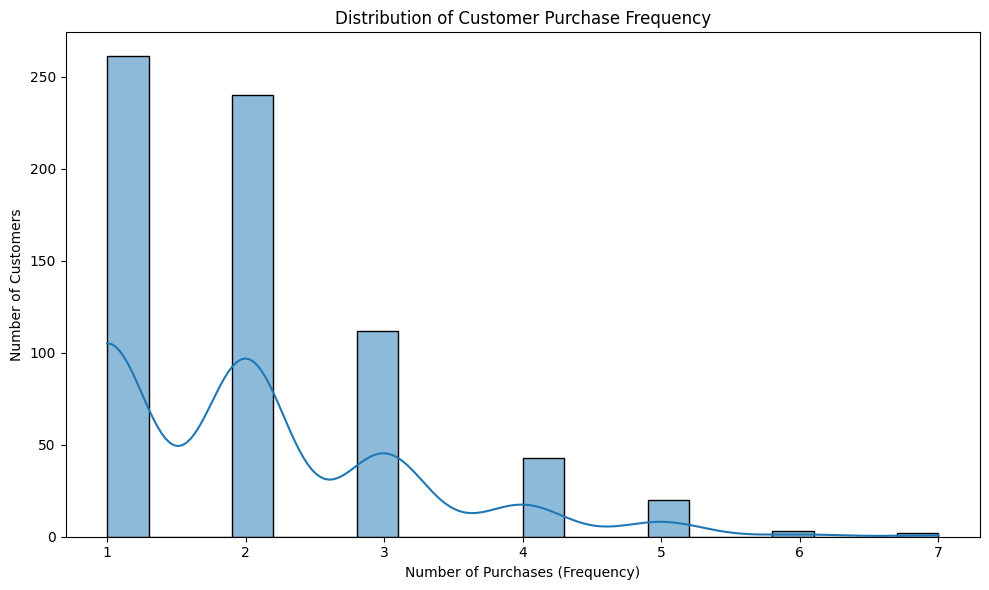

Interpretation: This graph illustrates how often customers buy, showing that most customers make a few purchases while some buy very frequently.

Descriptive statistics for Customer Purchase Frequency:
count    681.000000
mean       2.027900
std        1.099779
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        7.000000
Name: Frequency, dtype: float64


In [67]:
plt.figure(figsize=(10, 6))
sns.histplot(rfm_df['Frequency'], bins=20, kde=True)
plt.title('Distribution of Customer Purchase Frequency')
plt.xlabel('Number of Purchases (Frequency)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Interpretation: This graph illustrates how often customers buy, showing that most customers make a few purchases while some buy very frequently.")
print("\nDescriptive statistics for Customer Purchase Frequency:")
print(rfm_df['Frequency'].describe())

### What is the distribution of order value?

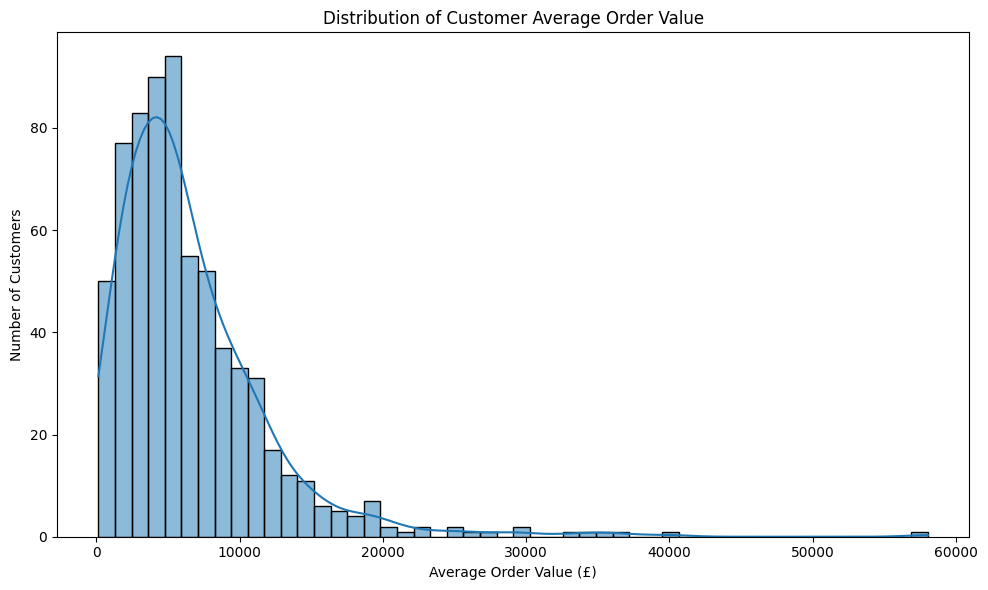

Interpretation: This graph shows the typical amount customers spend per order, indicating that most orders are smaller, but a few are very large.

Descriptive statistics for Customer Average Order Value:
count      681.000000
mean      6611.896227
std       5622.976164
min        151.940000
25%       3011.732500
50%       5242.452000
75%       8573.490000
max      58032.480000
Name: AverageOrderValue, dtype: float64


In [68]:
plt.figure(figsize=(10, 6))
sns.histplot(customer_features['AverageOrderValue'], bins=50, kde=True)
plt.title('Distribution of Customer Average Order Value')
plt.xlabel('Average Order Value (£)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Interpretation: This graph shows the typical amount customers spend per order, indicating that most orders are smaller, but a few are very large.")
print("\nDescriptive statistics for Customer Average Order Value:")
print(customer_features['AverageOrderValue'].describe())

### Are there outliers in quantity, price, or revenue?

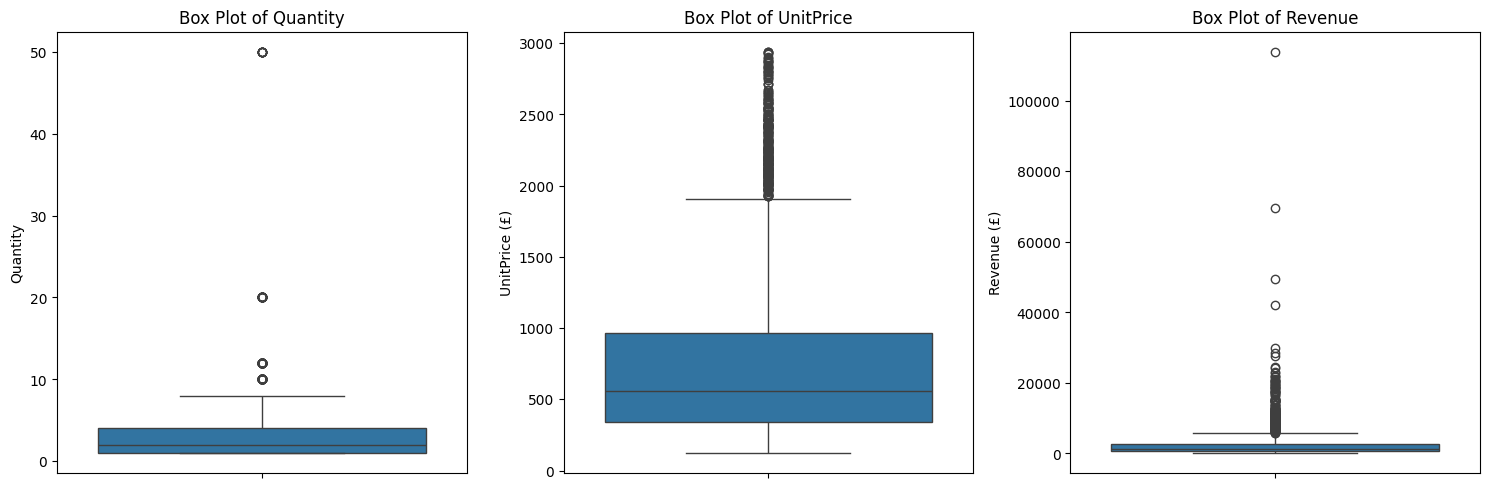

Interpretation: These graphs show how our quantities, prices, and revenues are spread out, highlighting any unusually high or low values.

Descriptive statistics for Quantity:
count    3848.000000
mean        3.121622
std         3.554803
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        50.000000
Name: Quantity, dtype: float64

Descriptive statistics for UnitPrice:
count    3848.000000
mean      769.308846
std       600.929764
min       122.480000
25%       338.512500
50%       558.195000
75%       968.007500
max      2939.580000
Name: UnitPrice, dtype: float64

Descriptive statistics for Revenue:
count      3848.000000
mean       2373.979641
std        3754.113344
min         123.080000
25%         645.620000
50%        1274.550000
75%        2760.825000
max      113890.000000
Name: Revenue, dtype: float64


In [69]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Box Plot of Quantity')
plt.ylabel('Quantity')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['UnitPrice'])
plt.title('Box Plot of UnitPrice')
plt.ylabel('UnitPrice (£)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Revenue'])
plt.title('Box Plot of Revenue')
plt.ylabel('Revenue (£)')

plt.tight_layout()
plt.show()

print("Interpretation: These graphs show how our quantities, prices, and revenues are spread out, highlighting any unusually high or low values.")
print("\nDescriptive statistics for Quantity:")
print(df['Quantity'].describe())
print("\nDescriptive statistics for UnitPrice:")
print(df['UnitPrice'].describe())
print("\nDescriptive statistics for Revenue:")
print(df['Revenue'].describe())

### Which customers appear to be high-value customers?

In [70]:
# High-value customers are typically those with high Monetary and high Frequency, and low Recency.
# sort by Monetary value to check who spends the most.
high_value_customers = rfm_df.sort_values(by='Monetary', ascending=False).head(10)
display(high_value_customers)

print("Interpretation: The table above shows the top 10 customers based on their total Monetary value. These customers contribute the most revenue and are considered high-value. Further analysis of their Recency and Frequency would provide more detailed insights into their loyalty and engagement.")

,CustomerID,Recency,Frequency,Monetary
551,C10684,76,2,116064.96
201,C10248,86,2,79880.85
127,C10151,41,4,75552.30
400,C10489,84,2,73697.71
317,C10391,126,2,59477.06
578,C10725,63,7,58475.82
310,C10383,21,2,55774.29
123,C10147,15,5,55598.45
397,C10485,131,5,53912.82
588,C10739,70,5,53240.09


Interpretation: The table above shows the top 10 customers based on their total Monetary value. These customers contribute the most revenue and are considered high-value. Further analysis of their Recency and Frequency would provide more detailed insights into their loyalty and engagement.


## 5. Customer Segmentation using K-Means

### Select Relevant Features and Scale Data

In [71]:
from sklearn.preprocessing import StandardScaler

# Select RFM features for clustering
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

# Scale the features
scaler = StandardScaler()
scaled_rfm_features = scaler.fit_transform(rfm_features)

# Convert back to DataFrame for better readability
scaled_rfm_df = pd.DataFrame(scaled_rfm_features, columns=rfm_features.columns)
display(scaled_rfm_df.head())

,Recency,Frequency,Monetary
0,-0.080051,0.884554,0.753723
1,-1.020730,-0.935329,-0.107681
2,-0.942340,-0.025388,-0.225540
3,1.935690,-0.025388,0.058916
4,-1.043127,0.884554,1.112097


### Use the Elbow Method to Choose a Suitable Number of Clusters

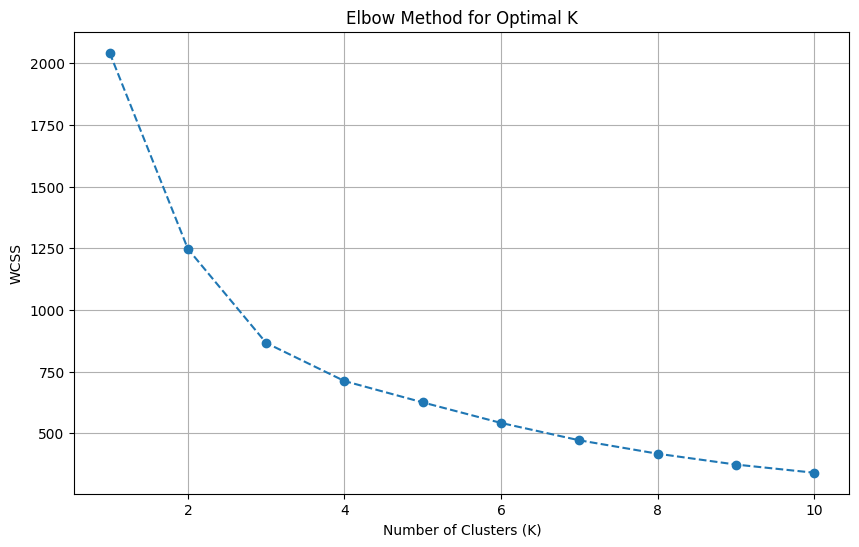

Interpretation: This graph helps us decide the best number of customer groups to create for our segmentation by looking for a 'bend' in the line.


In [72]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_rfm_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

print("Interpretation: This graph helps us decide the best number of customer groups to create for our segmentation by looking for a 'bend' in the line.")

### Train the K-Means Model and Assign Cluster Labels

,CustomerID,Recency,Frequency,Monetary,Cluster
0,C10001,117,3,22885.81,1
1,C10003,33,1,12061.04,0
2,C10004,40,2,10579.97,0
3,C10005,297,2,14154.57,2
4,C10006,31,3,27389.29,1


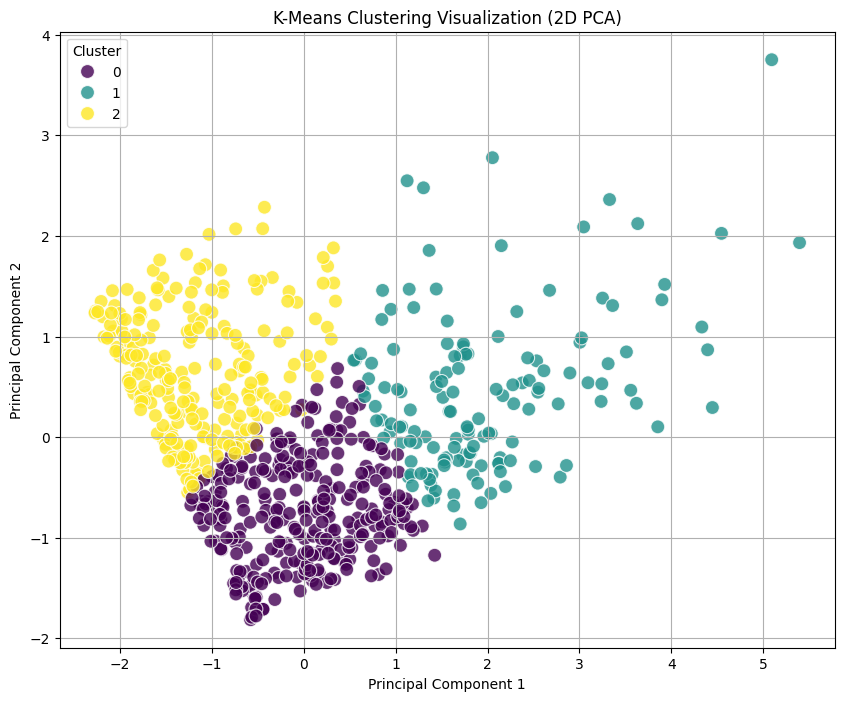

Interpretation: This chart visually separates customers into distinct groups based on their buying habits, showing how different segments are from each other.


In [73]:
optimal_k = 3 # Based on the elbow method plot
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Fit KMeans to the scaled data and assign cluster labels
rfm_df['Cluster'] = kmeans.fit_predict(scaled_rfm_features)

# Add cluster labels to the customer_features DataFrame as well
customer_features['Cluster'] = rfm_df['Cluster'].map(rfm_df.set_index('CustomerID')['Cluster'])

display(rfm_df.head())

# Start: Adding K-Means Clustering Diagram
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce dimensions to 2 for visualization using PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_rfm_features)

# Create a DataFrame for the principal components and clusters
pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = rfm_df['Cluster']

# Visualize the clusters in 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df,
                palette='viridis', s=100, alpha=0.8)
plt.title('K-Means Clustering Visualization (2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("Interpretation: This chart visually separates customers into distinct groups based on their buying habits, showing how different segments are from each other.")
# --- End: Adding K-Means Clustering Diagram ---

### Analyze Each Cluster

,Cluster,AvgRecency,AvgFrequency,AvgMonetary,NumCustomers
0,0,66.761745,1.805369,9370.575973,298
1,1,75.277778,3.534722,30601.338750,144
2,2,225.146444,1.397490,8100.624435,239


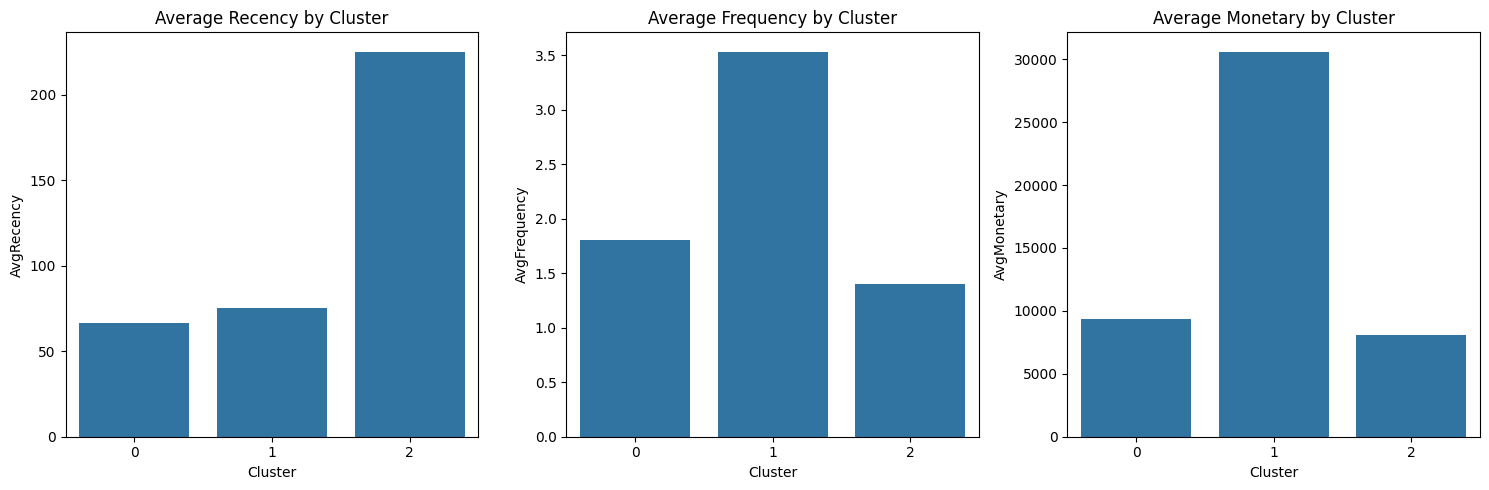

Interpretation: These graphs compare the average purchase recency, frequency, and total spending for each customer segment, clearly defining their unique characteristics.


In [74]:
cluster_analysis = rfm_df.groupby('Cluster').agg(
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    NumCustomers=('CustomerID', 'count')
).reset_index()

display(cluster_analysis)

# Visualize cluster profiles
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='Cluster', y='AvgRecency', data=cluster_analysis)
plt.title('Average Recency by Cluster')

plt.subplot(1, 3, 2)
sns.barplot(x='Cluster', y='AvgFrequency', data=cluster_analysis)
plt.title('Average Frequency by Cluster')

plt.subplot(1, 3, 3)
sns.barplot(x='Cluster', y='AvgMonetary', data=cluster_analysis)
plt.title('Average Monetary by Cluster')

plt.tight_layout()
plt.show()

print("Interpretation: These graphs compare the average purchase recency, frequency, and total spending for each customer segment, clearly defining their unique characteristics.")